In [190]:
!pip install mplfinance

In [191]:
!pip install yfinance

In [192]:
import pandas as pd
import yfinance as yf
import mplfinance as mpf

In [193]:
data = yf.download('AAPL', start='2020-01-01', end='2023-01-01')

[*********************100%***********************]  1 of 1 completed


In [194]:
if isinstance(data, pd.DataFrame):
    print("Data is a DataFrame")

Data is a DataFrame


In [195]:
if isinstance(data.columns, pd.MultiIndex):
    print("Data is a DataFrame")
    data.columns = data.columns.droplevel(1)

Data is a DataFrame


In [196]:
data.head(10)

Price,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,72.333878,72.394086,71.091184,71.344054,135480400
2020-01-03,71.630661,72.389280,71.406689,71.563228,146322800
2020-01-06,72.201401,72.239935,70.503539,70.754006,118387200
2020-01-07,71.861847,72.466330,71.642689,72.211049,108872000
2020-01-08,73.017838,73.318877,71.565621,71.565621,132079200
2020-01-09,74.568802,74.761465,73.742750,73.993210,170108400
2020-01-10,74.737373,75.300927,74.236446,74.802403,140644800
2020-01-13,76.334091,76.360587,74.934858,75.052871,121532000
2020-01-14,75.303329,76.481001,75.180510,76.271479,161954400


In [197]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 756 entries, 2020-01-02 to 2022-12-30
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   756 non-null    float64
 1   High    756 non-null    float64
 2   Low     756 non-null    float64
 3   Open    756 non-null    float64
 4   Volume  756 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 35.4 KB


In [198]:
data.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')

In [199]:
data.describe()


Price,Close,High,Low,Open,Volume
count,756.000000,756.000000,756.000000,756.000000,7.560000e+02
mean,127.128755,128.671053,125.473653,127.051113,1.120920e+08
std,30.301251,30.577591,30.020452,30.329239,5.602586e+07
min,54.163704,55.160702,51.324800,55.059313,3.519590e+07
25%,112.264151,113.753665,110.812212,112.443587,7.636470e+07
50%,132.485176,133.613799,130.532820,132.307403,9.493580e+07
75%,147.635777,148.798284,145.698857,147.005564,1.296327e+08
max,177.939713,178.848962,175.114380,178.545897,4.265100e+08


# Exploratory Data Analysis (EDA) on the stock data

## Visualization

In [200]:
import matplotlib.pyplot as plt
import seaborn as sns

<Figure size 1400x800 with 0 Axes>

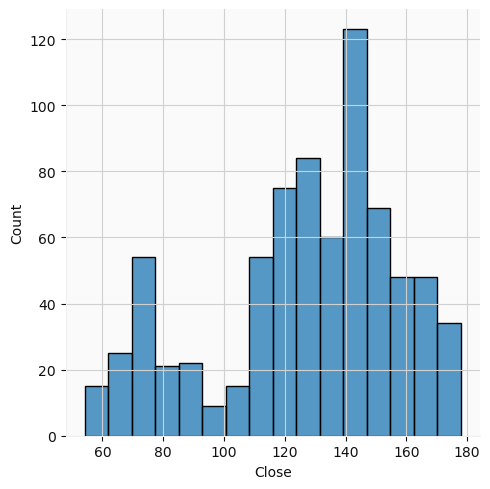

In [201]:
plt.figure(figsize=(14, 8))
sns.displot(data['Close'])
plt.show() 

<Figure size 1400x800 with 0 Axes>

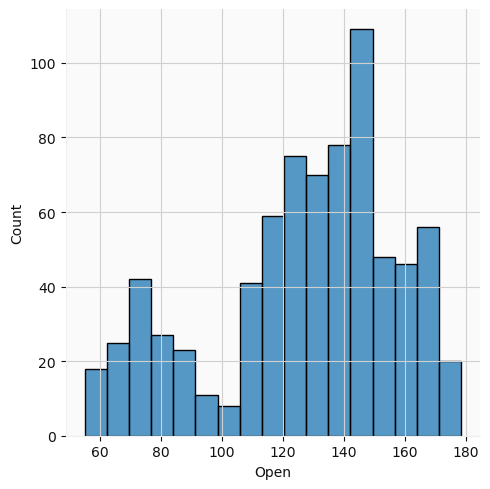

In [202]:
plt.figure(figsize=(14, 8))
sns.displot(data['Open'])
plt.show()

<Figure size 1400x800 with 0 Axes>

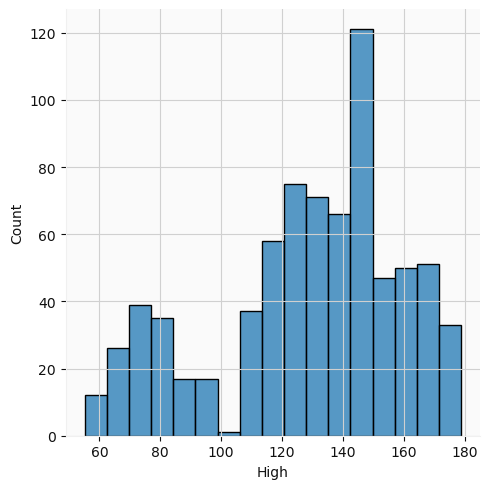

In [203]:
plt.figure(figsize=(14, 8))
sns.displot(data['High'])
plt.show()

<Figure size 1400x800 with 0 Axes>

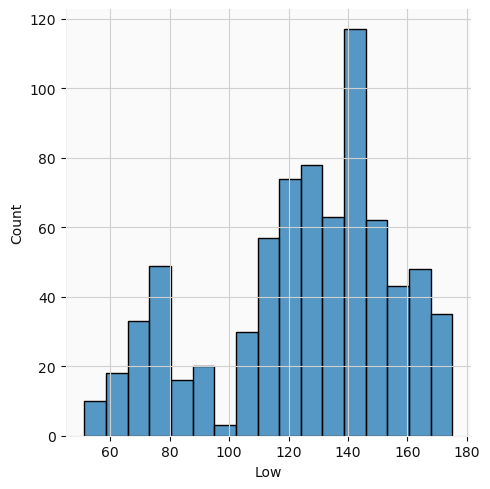

In [204]:
plt.figure(figsize=(14, 8))
sns.displot(data['Low'])
plt.show()

In [205]:
data.head()
type(data['Open'])

pandas.core.series.Series

In [206]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 756 entries, 2020-01-02 to 2022-12-30
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   756 non-null    float64
 1   High    756 non-null    float64
 2   Low     756 non-null    float64
 3   Open    756 non-null    float64
 4   Volume  756 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 35.4 KB


In [207]:
data['Open'] = data['Open'].astype(float)   

/opt/anaconda3/lib/python3.13/site-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


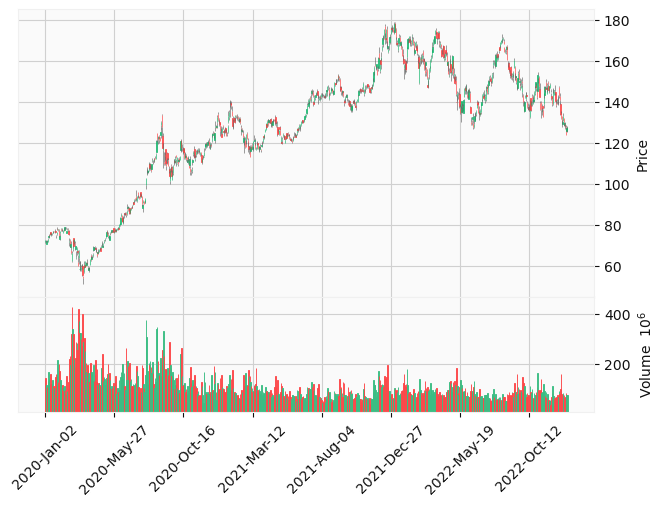

In [208]:
mpf.plot(
    data,
    type="candle",
    volume=True,
    style="yahoo"
)

Text(0.5, 1.0, 'Close Price with 20-Day Moving Average')

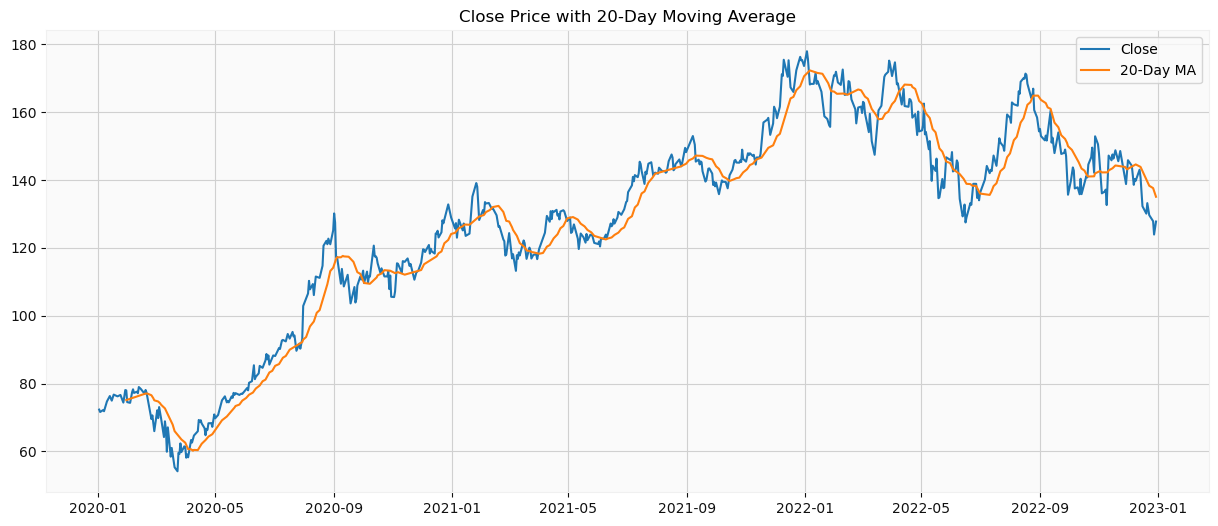

In [209]:
data["MA20"] = data["Close"].rolling(20).mean()

plt.figure(figsize=(15,6))

plt.plot(data.index, data["Close"], label="Close")
plt.plot(data.index, data["MA20"], label="20-Day MA")

plt.legend()
plt.title("Close Price with 20-Day Moving Average")

In [210]:
data['Close']

Date
2020-01-02     72.333878
2020-01-03     71.630661
2020-01-06     72.201401
2020-01-07     71.861847
2020-01-08     73.017838
                 ...    
2022-12-23    129.659409
2022-12-27    127.859940
2022-12-28    123.936531
2022-12-29    127.446938
2022-12-30    127.761620
Name: Close, Length: 756, dtype: float64

In [211]:
# finish visuals

In [212]:
#6 Volume

In [213]:
data["Volume_MA20"] = (
    data["Volume"]
    .rolling(20)
    .mean()
)

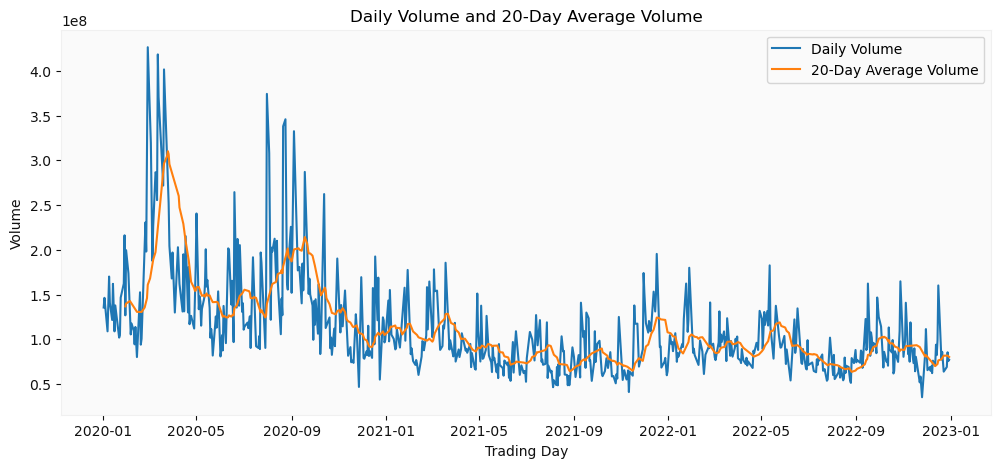

In [214]:
plt.figure(figsize=(12, 5))

plt.plot(data["Volume"], label="Daily Volume")
plt.plot(data["Volume_MA20"], label="20-Day Average Volume")

plt.title("Daily Volume and 20-Day Average Volume")
plt.xlabel("Trading Day")
plt.ylabel("Volume")
plt.legend()
plt.grid()

plt.show()

In [215]:
#Volume Change

In [216]:
data["Volume_Change"] = (
    data["Volume"]
    .pct_change()
)

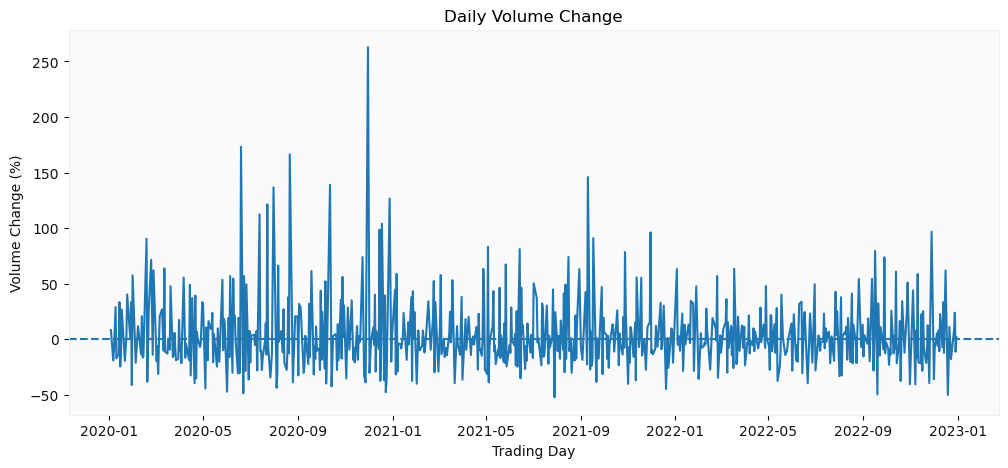

In [217]:
plt.figure(figsize=(12, 5))
plt.plot(data["Volume_Change"] * 100)
plt.axhline(y=0, linestyle="--")
plt.title("Daily Volume Change")
plt.xlabel("Trading Day")
plt.ylabel("Volume Change (%)")
plt.grid()

plt.show()

* We can see a high volume change during September 2020 - January 2021

In [218]:
#Relative volume

In [219]:
data["Relative_Volume"] = (
    data["Volume"] /
    data["Volume_MA20"]
)

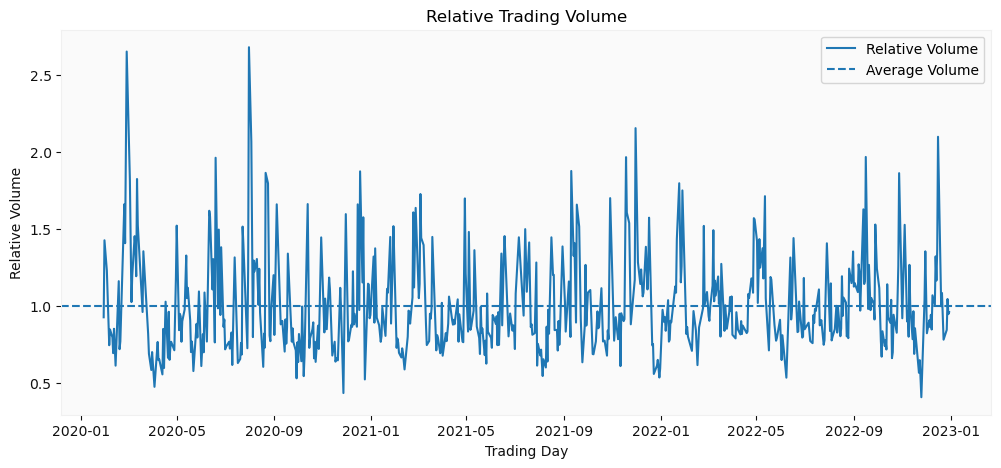

In [220]:
plt.figure(figsize=(12, 5))

plt.plot(
    data["Relative_Volume"],
    label="Relative Volume"
)

plt.axhline(
    y=1,
    linestyle="--",
    label="Average Volume"
)

plt.title("Relative Trading Volume")
plt.xlabel("Trading Day")
plt.ylabel("Relative Volume")
plt.legend()
plt.grid()

plt.show()

In [221]:
# 7

In [222]:
#Daily. Range

In [223]:
data["Daily_Range"] = (
    data["High"] -
    data["Low"]
)

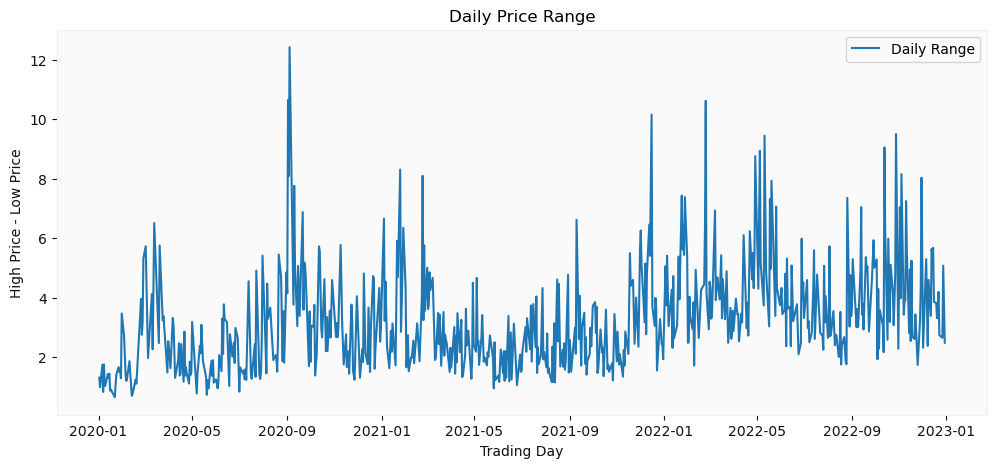

In [224]:
plt.figure(figsize=(12, 5))

plt.plot(
    data["Daily_Range"],
    label="Daily Range"
)

plt.title("Daily Price Range")
plt.xlabel("Trading Day")
plt.ylabel("High Price - Low Price")
plt.legend()
plt.grid()

plt.show()

In [225]:
#Close vs open

In [226]:
data["Close_Open_Diff"] = (
    data["Close"] -
    data["Open"]
)

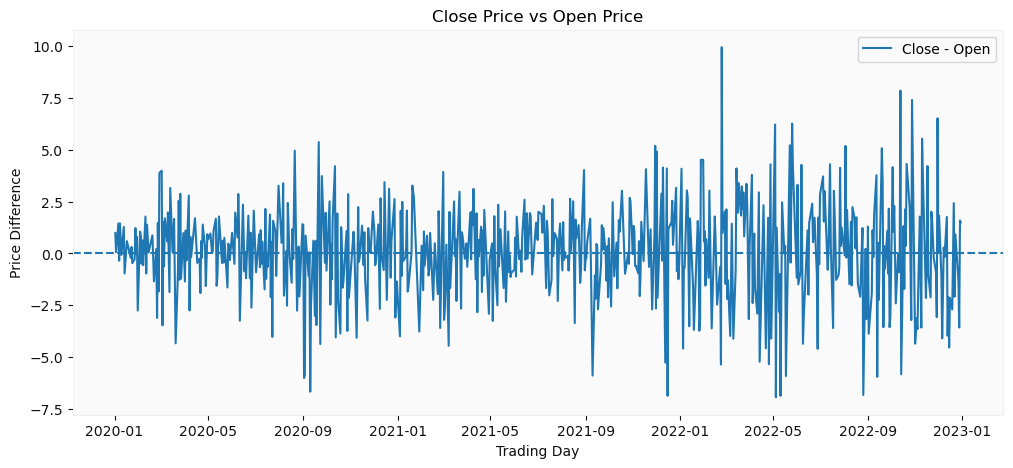

In [227]:
plt.figure(figsize=(12, 5))

plt.plot(
    data["Close_Open_Diff"],
    label="Close - Open"
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Close Price vs Open Price")
plt.xlabel("Trading Day")
plt.ylabel("Price Difference")
plt.legend()
plt.grid()

plt.show()

In [228]:
#High vs Close

In [229]:
data["High_Close_Diff"] = (
    data["High"] -
    data["Close"]
)

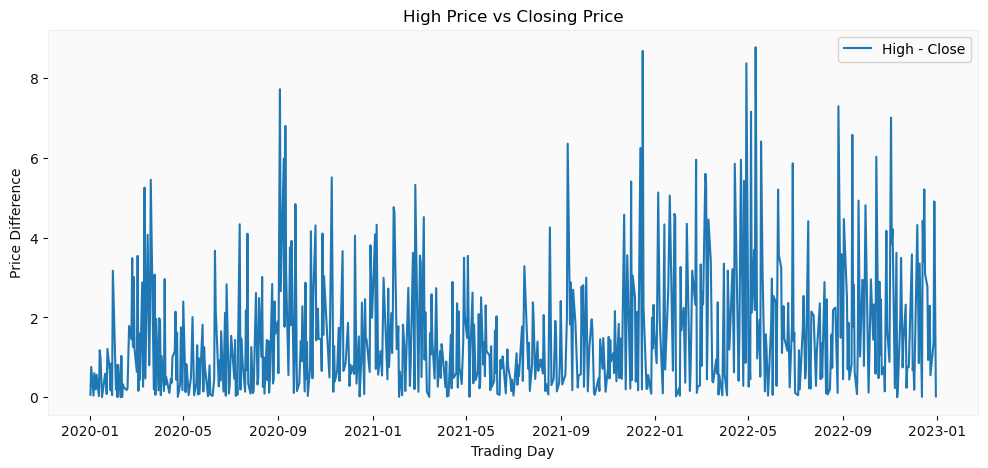

In [230]:
plt.figure(figsize=(12, 5))

plt.plot(
    data["High_Close_Diff"],
    label="High - Close"
)

plt.title("High Price vs Closing Price")
plt.xlabel("Trading Day")
plt.ylabel("Price Difference")
plt.legend()
plt.grid()

plt.show()

In [231]:
#8 Moving average features

In [232]:
data["MA10"] = data["Close"].rolling(10).mean()
data["MA20"] = data["Close"].rolling(20).mean()
data["MA50"] = data["Close"].rolling(50).mean()

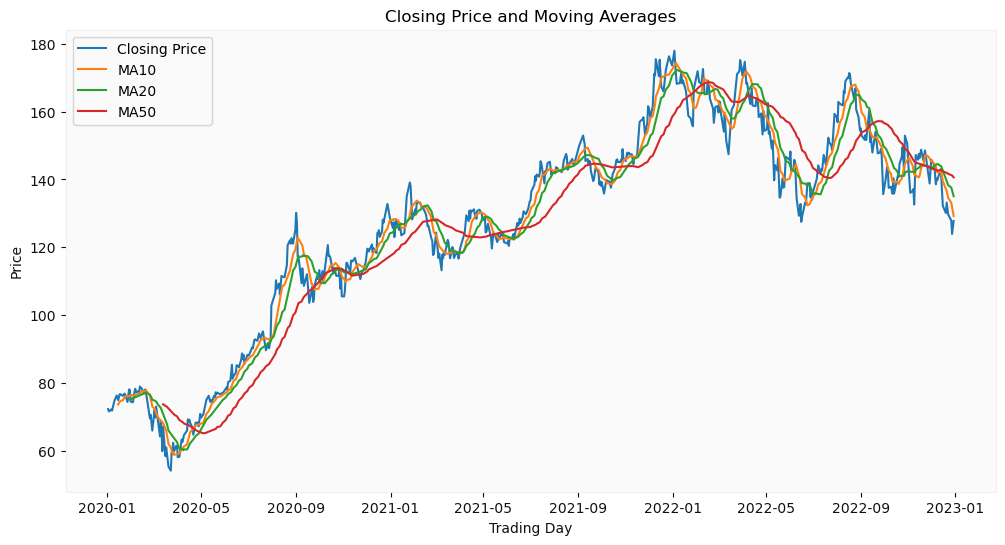

In [233]:
plt.figure(figsize=(12, 6))

plt.plot(data["Close"], label="Closing Price")
plt.plot(data["MA10"], label="MA10")
plt.plot(data["MA20"], label="MA20")
plt.plot(data["MA50"], label="MA50")

plt.title("Closing Price and Moving Averages")
plt.xlabel("Trading Day")
plt.ylabel("Price")
plt.legend()
plt.grid()

plt.show()

In [234]:
# Moving average diference

In [235]:
data["MA10_MA20"] = (
    data["MA10"] -
    data["MA20"]
)

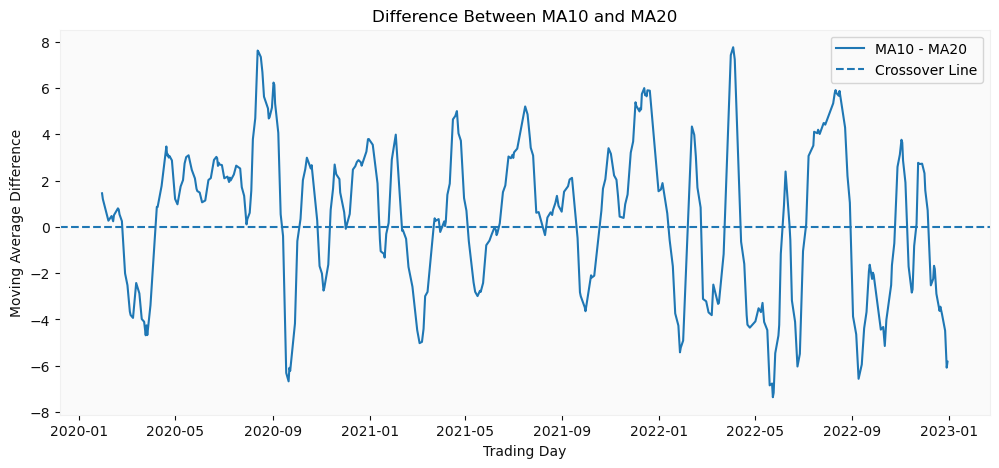

In [236]:
plt.figure(figsize=(12, 5))

plt.plot(
    data["MA10_MA20"],
    label="MA10 - MA20"
)

plt.axhline(
    y=0,
    linestyle="--",
    label="Crossover Line"
)

plt.title("Difference Between MA10 and MA20")
plt.xlabel("Trading Day")
plt.ylabel("Moving Average Difference")
plt.legend()
plt.grid()

plt.show()

## Feature Enginering

In [237]:
data.head(30)

Price,Close,High,Low,Open,Volume,MA20,Volume_MA20,Volume_Change,Relative_Volume,Daily_Range,Close_Open_Diff,High_Close_Diff,MA10,MA50,MA10_MA20
Date,,,,,,,,,,,,,,,
2020-01-02,72.333878,72.394086,71.091184,71.344054,135480400,NaN,NaN,NaN,NaN,1.302902,0.989823,0.060208,NaN,NaN,NaN
2020-01-03,71.630661,72.389280,71.406689,71.563228,146322800,NaN,NaN,0.080029,NaN,0.982591,0.067433,0.758619,NaN,NaN,NaN
2020-01-06,72.201401,72.239935,70.503539,70.754006,118387200,NaN,NaN,-0.190918,NaN,1.736396,1.447395,0.038534,NaN,NaN,NaN
2020-01-07,71.861847,72.466330,71.642689,72.211049,108872000,NaN,NaN,-0.080374,NaN,0.823641,-0.349202,0.604483,NaN,NaN,NaN
2020-01-08,73.017838,73.318877,71.565621,71.565621,132079200,NaN,NaN,0.213160,NaN,1.753256,1.452216,0.301040,NaN,NaN,NaN
2020-01-09,74.568802,74.761465,73.742750,73.993210,170108400,NaN,NaN,0.287927,NaN,1.018714,0.575592,0.192663,NaN,NaN,NaN
2020-01-10,74.737373,75.300927,74.236446,74.802403,140644800,NaN,NaN,-0.173205,NaN,1.064480,-0.065029,0.563553,NaN,NaN,NaN
2020-01-13,76.334091,76.360587,74.934858,75.052871,121532000,NaN,NaN,-0.135894,NaN,1.425728,1.281220,0.026495,NaN,NaN,NaN
2020-01-14,75.303329,76.481001,75.180510,76.271479,161954400,NaN,NaN,0.332607,NaN,1.300491,-0.968149,1.177672,NaN,NaN,NaN


In [238]:
data["MA50_Close"] = data["Close"].rolling(50).mean()
data.head(60)

Price,Close,High,Low,Open,Volume,MA20,Volume_MA20,Volume_Change,Relative_Volume,Daily_Range,Close_Open_Diff,High_Close_Diff,MA10,MA50,MA10_MA20,MA50_Close
Date,,,,,,,,,,,,,,,,
2020-01-02,72.333878,72.394086,71.091184,71.344054,135480400,NaN,NaN,NaN,NaN,1.302902,0.989823,0.060208,NaN,NaN,NaN,NaN
2020-01-03,71.630661,72.389280,71.406689,71.563228,146322800,NaN,NaN,0.080029,NaN,0.982591,0.067433,0.758619,NaN,NaN,NaN,NaN
2020-01-06,72.201401,72.239935,70.503539,70.754006,118387200,NaN,NaN,-0.190918,NaN,1.736396,1.447395,0.038534,NaN,NaN,NaN,NaN
2020-01-07,71.861847,72.466330,71.642689,72.211049,108872000,NaN,NaN,-0.080374,NaN,0.823641,-0.349202,0.604483,NaN,NaN,NaN,NaN
2020-01-08,73.017838,73.318877,71.565621,71.565621,132079200,NaN,NaN,0.213160,NaN,1.753256,1.452216,0.301040,NaN,NaN,NaN,NaN
2020-01-09,74.568802,74.761465,73.742750,73.993210,170108400,NaN,NaN,0.287927,NaN,1.018714,0.575592,0.192663,NaN,NaN,NaN,NaN
2020-01-10,74.737373,75.300927,74.236446,74.802403,140644800,NaN,NaN,-0.173205,NaN,1.064480,-0.065029,0.563553,NaN,NaN,NaN,NaN
2020-01-13,76.334091,76.360587,74.934858,75.052871,121532000,NaN,NaN,-0.135894,NaN,1.425728,1.281220,0.026495,NaN,NaN,NaN,NaN
2020-01-14,75.303329,76.481001,75.180510,76.271479,161954400,NaN,NaN,0.332607,NaN,1.300491,-0.968149,1.177672,NaN,NaN,NaN,NaN


In [239]:
data['Daily_Return'] = data['Close'].pct_change()
data.head(60)

Price,Close,High,Low,Open,Volume,MA20,Volume_MA20,Volume_Change,Relative_Volume,Daily_Range,Close_Open_Diff,High_Close_Diff,MA10,MA50,MA10_MA20,MA50_Close,Daily_Return
Date,,,,,,,,,,,,,,,,,
2020-01-02,72.333878,72.394086,71.091184,71.344054,135480400,NaN,NaN,NaN,NaN,1.302902,0.989823,0.060208,NaN,NaN,NaN,NaN,NaN
2020-01-03,71.630661,72.389280,71.406689,71.563228,146322800,NaN,NaN,0.080029,NaN,0.982591,0.067433,0.758619,NaN,NaN,NaN,NaN,-0.009722
2020-01-06,72.201401,72.239935,70.503539,70.754006,118387200,NaN,NaN,-0.190918,NaN,1.736396,1.447395,0.038534,NaN,NaN,NaN,NaN,0.007968
2020-01-07,71.861847,72.466330,71.642689,72.211049,108872000,NaN,NaN,-0.080374,NaN,0.823641,-0.349202,0.604483,NaN,NaN,NaN,NaN,-0.004703
2020-01-08,73.017838,73.318877,71.565621,71.565621,132079200,NaN,NaN,0.213160,NaN,1.753256,1.452216,0.301040,NaN,NaN,NaN,NaN,0.016086
2020-01-09,74.568802,74.761465,73.742750,73.993210,170108400,NaN,NaN,0.287927,NaN,1.018714,0.575592,0.192663,NaN,NaN,NaN,NaN,0.021241
2020-01-10,74.737373,75.300927,74.236446,74.802403,140644800,NaN,NaN,-0.173205,NaN,1.064480,-0.065029,0.563553,NaN,NaN,NaN,NaN,0.002261
2020-01-13,76.334091,76.360587,74.934858,75.052871,121532000,NaN,NaN,-0.135894,NaN,1.425728,1.281220,0.026495,NaN,NaN,NaN,NaN,0.021364
2020-01-14,75.303329,76.481001,75.180510,76.271479,161954400,NaN,NaN,0.332607,NaN,1.300491,-0.968149,1.177672,NaN,NaN,NaN,NaN,-0.013503


## Calendar Features

In [240]:
data.head()

Price,Close,High,Low,Open,Volume,MA20,Volume_MA20,Volume_Change,Relative_Volume,Daily_Range,Close_Open_Diff,High_Close_Diff,MA10,MA50,MA10_MA20,MA50_Close,Daily_Return
Date,,,,,,,,,,,,,,,,,
2020-01-02,72.333878,72.394086,71.091184,71.344054,135480400,NaN,NaN,NaN,NaN,1.302902,0.989823,0.060208,NaN,NaN,NaN,NaN,NaN
2020-01-03,71.630661,72.389280,71.406689,71.563228,146322800,NaN,NaN,0.080029,NaN,0.982591,0.067433,0.758619,NaN,NaN,NaN,NaN,-0.009722
2020-01-06,72.201401,72.239935,70.503539,70.754006,118387200,NaN,NaN,-0.190918,NaN,1.736396,1.447395,0.038534,NaN,NaN,NaN,NaN,0.007968
2020-01-07,71.861847,72.466330,71.642689,72.211049,108872000,NaN,NaN,-0.080374,NaN,0.823641,-0.349202,0.604483,NaN,NaN,NaN,NaN,-0.004703
2020-01-08,73.017838,73.318877,71.565621,71.565621,132079200,NaN,NaN,0.213160,NaN,1.753256,1.452216,0.301040,NaN,NaN,NaN,NaN,0.016086


In [241]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 756 entries, 2020-01-02 to 2022-12-30
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Close            756 non-null    float64
 1   High             756 non-null    float64
 2   Low              756 non-null    float64
 3   Open             756 non-null    float64
 4   Volume           756 non-null    int64  
 5   MA20             737 non-null    float64
 6   Volume_MA20      737 non-null    float64
 7   Volume_Change    755 non-null    float64
 8   Relative_Volume  737 non-null    float64
 9   Daily_Range      756 non-null    float64
 10  Close_Open_Diff  756 non-null    float64
 11  High_Close_Diff  756 non-null    float64
 12  MA10             747 non-null    float64
 13  MA50             707 non-null    float64
 14  MA10_MA20        737 non-null    float64
 15  MA50_Close       707 non-null    float64
 16  Daily_Return     755 non-null    float64
dt

In [242]:
data.index

DatetimeIndex(['2020-01-02', '2020-01-03', '2020-01-06', '2020-01-07',
               '2020-01-08', '2020-01-09', '2020-01-10', '2020-01-13',
               '2020-01-14', '2020-01-15',
               ...
               '2022-12-16', '2022-12-19', '2022-12-20', '2022-12-21',
               '2022-12-22', '2022-12-23', '2022-12-27', '2022-12-28',
               '2022-12-29', '2022-12-30'],
              dtype='datetime64[ns]', name='Date', length=756, freq=None)

In [243]:
data["Day"] = data.index.day

In [244]:
data.head()

Price,Close,High,Low,Open,Volume,MA20,Volume_MA20,Volume_Change,Relative_Volume,Daily_Range,Close_Open_Diff,High_Close_Diff,MA10,MA50,MA10_MA20,MA50_Close,Daily_Return,Day
Date,,,,,,,,,,,,,,,,,,
2020-01-02,72.333878,72.394086,71.091184,71.344054,135480400,NaN,NaN,NaN,NaN,1.302902,0.989823,0.060208,NaN,NaN,NaN,NaN,NaN,2
2020-01-03,71.630661,72.389280,71.406689,71.563228,146322800,NaN,NaN,0.080029,NaN,0.982591,0.067433,0.758619,NaN,NaN,NaN,NaN,-0.009722,3
2020-01-06,72.201401,72.239935,70.503539,70.754006,118387200,NaN,NaN,-0.190918,NaN,1.736396,1.447395,0.038534,NaN,NaN,NaN,NaN,0.007968,6
2020-01-07,71.861847,72.466330,71.642689,72.211049,108872000,NaN,NaN,-0.080374,NaN,0.823641,-0.349202,0.604483,NaN,NaN,NaN,NaN,-0.004703,7
2020-01-08,73.017838,73.318877,71.565621,71.565621,132079200,NaN,NaN,0.213160,NaN,1.753256,1.452216,0.301040,NaN,NaN,NaN,NaN,0.016086,8


In [245]:
data["Weekday"] = data.index.weekday

In [246]:
data.head()

Price,Close,High,Low,Open,Volume,MA20,Volume_MA20,Volume_Change,Relative_Volume,Daily_Range,Close_Open_Diff,High_Close_Diff,MA10,MA50,MA10_MA20,MA50_Close,Daily_Return,Day,Weekday
Date,,,,,,,,,,,,,,,,,,,
2020-01-02,72.333878,72.394086,71.091184,71.344054,135480400,NaN,NaN,NaN,NaN,1.302902,0.989823,0.060208,NaN,NaN,NaN,NaN,NaN,2,3
2020-01-03,71.630661,72.389280,71.406689,71.563228,146322800,NaN,NaN,0.080029,NaN,0.982591,0.067433,0.758619,NaN,NaN,NaN,NaN,-0.009722,3,4
2020-01-06,72.201401,72.239935,70.503539,70.754006,118387200,NaN,NaN,-0.190918,NaN,1.736396,1.447395,0.038534,NaN,NaN,NaN,NaN,0.007968,6,0
2020-01-07,71.861847,72.466330,71.642689,72.211049,108872000,NaN,NaN,-0.080374,NaN,0.823641,-0.349202,0.604483,NaN,NaN,NaN,NaN,-0.004703,7,1
2020-01-08,73.017838,73.318877,71.565621,71.565621,132079200,NaN,NaN,0.213160,NaN,1.753256,1.452216,0.301040,NaN,NaN,NaN,NaN,0.016086,8,2


In [247]:
data["Month"]= data.index.month

In [248]:
data.head()

Price,Close,High,Low,Open,Volume,MA20,Volume_MA20,Volume_Change,Relative_Volume,Daily_Range,Close_Open_Diff,High_Close_Diff,MA10,MA50,MA10_MA20,MA50_Close,Daily_Return,Day,Weekday,Month
Date,,,,,,,,,,,,,,,,,,,,
2020-01-02,72.333878,72.394086,71.091184,71.344054,135480400,NaN,NaN,NaN,NaN,1.302902,0.989823,0.060208,NaN,NaN,NaN,NaN,NaN,2,3,1
2020-01-03,71.630661,72.389280,71.406689,71.563228,146322800,NaN,NaN,0.080029,NaN,0.982591,0.067433,0.758619,NaN,NaN,NaN,NaN,-0.009722,3,4,1
2020-01-06,72.201401,72.239935,70.503539,70.754006,118387200,NaN,NaN,-0.190918,NaN,1.736396,1.447395,0.038534,NaN,NaN,NaN,NaN,0.007968,6,0,1
2020-01-07,71.861847,72.466330,71.642689,72.211049,108872000,NaN,NaN,-0.080374,NaN,0.823641,-0.349202,0.604483,NaN,NaN,NaN,NaN,-0.004703,7,1,1
2020-01-08,73.017838,73.318877,71.565621,71.565621,132079200,NaN,NaN,0.213160,NaN,1.753256,1.452216,0.301040,NaN,NaN,NaN,NaN,0.016086,8,2,1


In [249]:
data["Year"] = data.index.year

In [250]:
data.head()

Price,Close,High,Low,Open,Volume,MA20,Volume_MA20,Volume_Change,Relative_Volume,Daily_Range,...,High_Close_Diff,MA10,MA50,MA10_MA20,MA50_Close,Daily_Return,Day,Weekday,Month,Year
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-02,72.333878,72.394086,71.091184,71.344054,135480400,NaN,NaN,NaN,NaN,1.302902,...,0.060208,NaN,NaN,NaN,NaN,NaN,2,3,1,2020
2020-01-03,71.630661,72.389280,71.406689,71.563228,146322800,NaN,NaN,0.080029,NaN,0.982591,...,0.758619,NaN,NaN,NaN,NaN,-0.009722,3,4,1,2020
2020-01-06,72.201401,72.239935,70.503539,70.754006,118387200,NaN,NaN,-0.190918,NaN,1.736396,...,0.038534,NaN,NaN,NaN,NaN,0.007968,6,0,1,2020
2020-01-07,71.861847,72.466330,71.642689,72.211049,108872000,NaN,NaN,-0.080374,NaN,0.823641,...,0.604483,NaN,NaN,NaN,NaN,-0.004703,7,1,1,2020
2020-01-08,73.017838,73.318877,71.565621,71.565621,132079200,NaN,NaN,0.213160,NaN,1.753256,...,0.301040,NaN,NaN,NaN,NaN,0.016086,8,2,1,2020


In [251]:
# mean imputation
data['MA20']= data['MA20'].fillna(data['MA20'].mean())
data['MA50_Close']= data['MA50_Close'].fillna(data['MA50_Close'].mean())
data['Daily_Return']= data['Daily_Return'].fillna(data['Daily_Return'].mean())

In [252]:
data.head()

Price,Close,High,Low,Open,Volume,MA20,Volume_MA20,Volume_Change,Relative_Volume,Daily_Range,...,High_Close_Diff,MA10,MA50,MA10_MA20,MA50_Close,Daily_Return,Day,Weekday,Month,Year
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-02,72.333878,72.394086,71.091184,71.344054,135480400,127.756422,NaN,NaN,NaN,1.302902,...,0.060208,NaN,NaN,NaN,128.563919,0.001024,2,3,1,2020
2020-01-03,71.630661,72.389280,71.406689,71.563228,146322800,127.756422,NaN,0.080029,NaN,0.982591,...,0.758619,NaN,NaN,NaN,128.563919,-0.009722,3,4,1,2020
2020-01-06,72.201401,72.239935,70.503539,70.754006,118387200,127.756422,NaN,-0.190918,NaN,1.736396,...,0.038534,NaN,NaN,NaN,128.563919,0.007968,6,0,1,2020
2020-01-07,71.861847,72.466330,71.642689,72.211049,108872000,127.756422,NaN,-0.080374,NaN,0.823641,...,0.604483,NaN,NaN,NaN,128.563919,-0.004703,7,1,1,2020
2020-01-08,73.017838,73.318877,71.565621,71.565621,132079200,127.756422,NaN,0.213160,NaN,1.753256,...,0.301040,NaN,NaN,NaN,128.563919,0.016086,8,2,1,2020


## Feature Selection

In [253]:
data.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'MA20', 'Volume_MA20',
       'Volume_Change', 'Relative_Volume', 'Daily_Range', 'Close_Open_Diff',
       'High_Close_Diff', 'MA10', 'MA50', 'MA10_MA20', 'MA50_Close',
       'Daily_Return', 'Day', 'Weekday', 'Month', 'Year'],
      dtype='object', name='Price')

In [254]:
x = data.drop(columns = ['Close'], axis = 1)


In [255]:
y = data['Close']

## Time-Series (Train, Test, Split)

In [256]:
# Normal dataset
from sklearn.model_selection import train_test_split

In [257]:
train_size = int(len(x)*0.7)
val_size = int(len(x)*0.3)

In [258]:
x_train = x.iloc[:train_size]
y_train = y.iloc[:train_size]

In [259]:
train_size

529

In [260]:
x_test = x.iloc[train_size:]
y_test = y.iloc[train_size:]


In [261]:
print(f"x_train = {x_train.shape}")
print(f"y_train = {y_train.shape}")

x_train = (529, 20)
y_train = (529,)


In [262]:
print(f"x_test = {x_test.shape}")
print(f"y_test = {y_test.shape}")

x_test = (227, 20)
y_test = (227,)


## Model Training 

In [263]:
from sklearn.linear_model import LinearRegression

In [264]:
model = LinearRegression()

In [265]:
x.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 756 entries, 2020-01-02 to 2022-12-30
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   High             756 non-null    float64
 1   Low              756 non-null    float64
 2   Open             756 non-null    float64
 3   Volume           756 non-null    int64  
 4   MA20             756 non-null    float64
 5   Volume_MA20      737 non-null    float64
 6   Volume_Change    755 non-null    float64
 7   Relative_Volume  737 non-null    float64
 8   Daily_Range      756 non-null    float64
 9   Close_Open_Diff  756 non-null    float64
 10  High_Close_Diff  756 non-null    float64
 11  MA10             747 non-null    float64
 12  MA50             707 non-null    float64
 13  MA10_MA20        737 non-null    float64
 14  MA50_Close       756 non-null    float64
 15  Daily_Return     756 non-null    float64
 16  Day              756 non-null    int32  
 1

In [266]:
x.isna().sum()

Price
High                0
Low                 0
Open                0
Volume              0
MA20                0
Volume_MA20        19
Volume_Change       1
Relative_Volume    19
Daily_Range         0
Close_Open_Diff     0
High_Close_Diff     0
MA10                9
MA50               49
MA10_MA20          19
MA50_Close          0
Daily_Return        0
Day                 0
Weekday             0
Month               0
Year                0
dtype: int64

In [267]:
model.fit(x_train, y_train)


ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
predictions = model.predict(x_test)

In [ ]:
predictions

array([168.51284826, 170.7504477 , 172.03275449, 169.06417035,
       166.10736574, 164.72120548, 168.76452482, 168.03319494,
       165.84144758, 164.33113109, 160.47335413, 158.49075581,
       156.76230664, 159.89189962, 160.73459705, 160.58462403,
       162.656541  , 163.39035889, 159.79238509, 157.9189386 ,
       156.22161311, 159.13767624, 153.75809914, 152.65918756,
       148.51869467, 151.50401023, 155.12875367, 156.48067618,
       159.92383325, 161.78026881, 164.83896174, 167.54333893,
       169.54974712, 170.41052807, 170.78236723, 174.55895279,
       173.97832196, 171.52422679, 169.52275225, 173.95636087,
       171.8285546 , 167.62256237, 168.21878862, 166.19415256,
       162.69759383, 165.12731872, 166.38724762, 163.49158162,
       161.92778744, 163.14768535, 163.6101807 , 165.27795165,
       160.38861016, 157.75083596, 154.72005811, 154.93715062,
       160.54723631, 157.91583157, 152.50808923, 155.78265423,
       161.95099377, 154.10217047, 154.42263716, 149.54

In [ ]:
data_pred = pd.DataFrame(y_test)
data_pred['Predictions Value'] = predictions
#data_pred['Actual Value'] = y_test


In [ ]:
data_pred

,Close,Predictions Value
Date,,
2022-02-07,168.035019,168.512848
2022-02-08,171.138062,170.750448
2022-02-09,172.557434,172.032754
2022-02-10,168.485260,169.064170
2022-02-11,165.078781,166.107366
...,...,...
2022-12-23,129.659424,129.268460
2022-12-27,127.859924,127.564805
2022-12-28,123.936523,125.799297


## Model Evaluation

In [ ]:
from sklearn.metrics import root_mean_squared_error, mean_squared_error

In [ ]:
#Calculate mse
mse = mean_squared_error(y_test, predictions)

In [ ]:
print(f"MSE:{mse:.4f}")

MSE:0.9219


In [ ]:
rmse = root_mean_squared_error(y_test, predictions)
print(f"RMSE:{rmse:.4f}")

RMSE:0.9602
